In [248]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [249]:
df_train = pd.read_csv('/kaggle/input/competitions/playground-series-s5e10/train.csv')

In [250]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [251]:
df_train.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [252]:
df_train.columns

Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='object')

In [253]:
df_train = df_train.drop('id', axis = 1)

In [254]:
df_train['road_type'].unique()

array(['urban', 'rural', 'highway'], dtype=object)

In [255]:
df_train = pd.get_dummies(df_train, columns=['road_type'], drop_first=True, dtype=int)

In [256]:
df_train = pd.get_dummies(df_train, columns=['lighting'], drop_first=True, dtype=int)

In [257]:
df_train = pd.get_dummies(df_train, columns=['weather'], drop_first=True, dtype=int)

In [258]:
df_train['road_signs_present'] = df_train['road_signs_present'].apply(lambda x: 1 if x == True else 0)

In [259]:
df_train['public_road'] = df_train['public_road'].apply(lambda x: 1 if x == True else 0)

In [260]:
df_train = pd.get_dummies(df_train, columns= ['time_of_day'], drop_first=True, dtype=int)

In [261]:
df_train['holiday'] = df_train['holiday'].apply(lambda x: 1 if x == True else 0)

In [262]:
df_train['school_season'] = df_train['school_season'].apply(lambda x: 1 if x == True else 0)

In [263]:
X = df_train.drop('accident_risk',axis=1)
y = df_train['accident_risk']

In [264]:
from sklearn.model_selection import train_test_split

In [265]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [266]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [267]:
scaler = StandardScaler()
model = SGDRegressor()
pipe = Pipeline([('scaler',scaler),('model',model)])

In [268]:
params = {
    'scaler' : [StandardScaler(),None, MinMaxScaler()],
    'model__alpha' : [0.001,0.0001,0.00001],
    'model__eta0' : [0.001,0.0001, 0.00001]
}

In [269]:
final_model = GridSearchCV(pipe,param_grid=params,cv=3,verbose=2)

In [270]:
final_model.fit(X_train,y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END model__alpha=0.001, model__eta0=0.001, scaler=StandardScaler(); total time=   0.6s
[CV] END model__alpha=0.001, model__eta0=0.001, scaler=StandardScaler(); total time=   0.6s
[CV] END model__alpha=0.001, model__eta0=0.001, scaler=StandardScaler(); total time=   0.6s
[CV] END .model__alpha=0.001, model__eta0=0.001, scaler=None; total time=   0.5s
[CV] END .model__alpha=0.001, model__eta0=0.001, scaler=None; total time=   0.6s
[CV] END .model__alpha=0.001, model__eta0=0.001, scaler=None; total time=   0.6s
[CV] END model__alpha=0.001, model__eta0=0.001, scaler=MinMaxScaler(); total time=   0.6s
[CV] END model__alpha=0.001, model__eta0=0.001, scaler=MinMaxScaler(); total time=   0.6s
[CV] END model__alpha=0.001, model__eta0=0.001, scaler=MinMaxScaler(); total time=   0.6s
[CV] END model__alpha=0.001, model__eta0=0.0001, scaler=StandardScaler(); total time=   0.7s
[CV] END model__alpha=0.001, model__eta0=0.0001, scaler=S

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', SGDRegressor())]),
             param_grid={'model__alpha': [0.001, 0.0001, 1e-05],
                         'model__eta0': [0.001, 0.0001, 1e-05],
                         'scaler': [StandardScaler(), None, MinMaxScaler()]},
             verbose=2)

In [271]:
y_pred = final_model.predict(X_test)

In [272]:
from sklearn.metrics import mean_absolute_error

In [273]:
mean_absolute_error(y_test, y_pred)

0.05831230869163165

In [274]:
final_model.best_score_

np.float64(0.8051224716862437)

Text(0.5, 1.0, 'Actual vs Predicted')

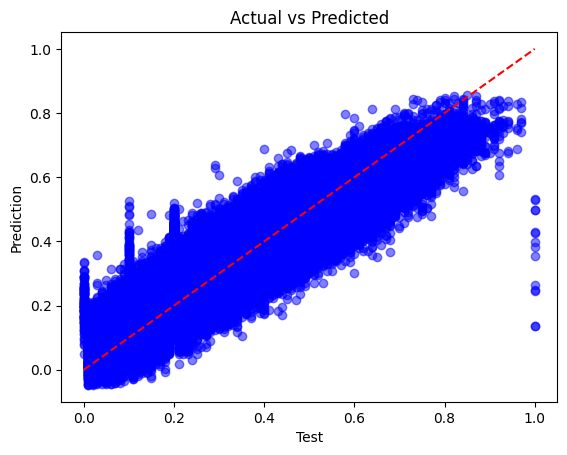

In [279]:
plt.scatter(y_test,y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Test')
plt.ylabel('Prediction')
plt.title('Actual vs Predicted')

In [276]:
import joblib

In [277]:
joblib.dump(final_model, 'road_accident_risk_model.pkl')

['road_accident_risk_model.pkl']